# Plausible-value check: `tas`, `tasmax`, `tasmin`, `pr`, `rsds`

This notebook checks whether the downscaled temperature, precipitation, and shortwave radiation
outputs stay inside a *location- and season-aware* plausible range. The global sanity bounds used
elsewhere (the "reasonable ranges" Check 3 in the [output-integrity notebook](output-integrity-checks.ipynb))
catch gross errors such as a mean temperature of 500 K, but they say nothing about values that are
globally ordinary yet locally impossible. A daily maximum of 25 °C is unremarkable in most of the
world, but in Antarctica in winter it should raise eyebrows.

To catch that second class of problem we build, for every grid cell and every day of the year, a
plausible envelope from the coarse GCM's modeled day-of-year variability (scenario relative to
historical) added to the observed ERA5 day-of-year envelope. We then ask, per leaf, what fraction of
the domain ever leaves that envelope, and by how much. The check is deliberately wide: it is meant to
flag suspect cells for inspection, not to fail a leaf on a single warm afternoon.

For precipitation the envelope is built the same additive way, but only its upper bound carries
information. Precipitation cannot go below zero, so the lower bound — the observed day-of-year
minimum plus the modeled change — is usually negative and so almost never flags a cell: in this run
it catches at most 0.003 % of the domain, and by no more than about 3 mm day⁻¹, in the persistently
wet cells where the observed day-of-year minimum sits above zero. The precipitation check therefore
measures how far the downscaled output rises above the wettest observed day plus the coarse model's
modeled increase. The same additive lower bound can go negative for any variable that is physically
nonnegative, so `pr`, `rsds`, and `hurs` all have their lower bound floored at zero before comparison
(see `plausibility_stats` in Part 1). Exceedance magnitudes and map color scales are reported in the
units that make each variable easiest to judge rather than assuming kelvin throughout: kelvin for
`tas`/`tasmax`/`tasmin`, mm day⁻¹ for `pr`, and W m⁻² for `rsds`. The stored `pr` array keeps the
CMIP convention of kg m⁻² s⁻¹ and this notebook never rewrites it, but that unit is hard to reason
about: the largest precipitation exceedance in this run is 0.00996 kg m⁻² s⁻¹, which reads as a
formidable 860 mm day⁻¹. Multiplying by the 86400 seconds in a day is the entire conversion, because
the 1000 mm m⁻¹ and the 1000 kg m⁻³ density of water cancel, and it is applied only where numbers are
reported.

The notebook follows the structure of the output-integrity notebook: open the output store once,
discover the `(scenario, variable, member)` leaves programmatically, express every reduction lazily,
and materialize them one `dask.compute` per variable. That batching keeps the leaves of each variable
running in parallel instead of one-at-a-time, which is the change that lets it scale past a
single-region test.

In [1]:
import functools
import os
import pathlib
import time

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import coiled
import dask
import icechunk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import zarr
from dask_array.xarray import register

from srm import catalog
from srm.config import ClusterConfig, _icechunk_storage_for_path
from srm.lineage import resolve_member_lineage
from srm.qaqc import obs_doy_bounds, scenario_delta_doy

os.environ["FRISKY_SUMMARY"] = "off"
from frisky import hijack

# Activate frisky's query-optimized dask array backend for xarray before opening any store,
# so every array uses one backend (see https://matthewrocklin.com/frisky-xarray/).
register()

zarr.config.set({"async.concurrency": 128})

# --- Run parameters --------------------------------------------------------
# v0.11.1 is the latest production run; it carries the tas/tasmax/tasmin triplet and precipitation (pr).
GCM = "CESM2-WACCM"
STORE_URI = "s3://us-west-2.opendata.source.coop/carbonplan/srm-downscaling/output/production/CESM2-WACCM-ERA5-global.icechunk"
BRANCH = "v0.12.0"
VARIABLES = ["tas", "tasmax", "tasmin", "pr", "rsds"]
SPATIAL = ["lat", "lon"]

# Bounds construction: obs baseline start year and day-of-year rolling window
# (window matches the srm.qaqc default).
OBS_START_YEAR = 1978
WINDOW = 30

# A leaf is flagged when more than this fraction of the domain leaves the envelope.
FLAG_THRESHOLD = 0.02

# Reporting units, applied only when a magnitude is printed or plotted -- the stored arrays keep
# the CMIP conventions untouched. Kelvin reads fine, but a precipitation rate in kg m-2 s-1 does
# not: 1e-4 kg m-2 s-1 is an ordinary wet day, so `pr` is reported in mm day-1. The factor is just
# the 86400 seconds in a day, since the 1000 mm m-1 and the 1000 kg m-3 density of water cancel.
# A variable absent from this map is reported in its stored units with a factor of 1.
DISPLAY_UNITS: dict[str, tuple[str, float]] = {"pr": ("mm day-1", 86400.0)}

# Per-leaf CSV + PNG artifacts (kept from the original notebook for downstream use).
QAQC_DIR = "/scratch/synced/qa_plots/plausible_value_check/"

# Optional fast path for a quick regional test run: set to (lat_slice, lon_slice)
# in the store's coordinate convention, or None to check the whole globe.
SUBSET = None
# SUBSET = (slice(-35, -22), slice(16, 33))  # the original Namibia test box


def apply_subset(da: xr.DataArray) -> xr.DataArray:
    """Restrict to SUBSET for a fast regional run; identity when SUBSET is None."""
    if SUBSET is None:
        return da
    lat_slice, lon_slice = SUBSET
    return da.sel(lat=lat_slice, lon=lon_slice)

## Compute

The output store lives in S3 in `us-west-2` and the check reads every cell of the fine-grid
temperature, precipitation, and shortwave radiation arrays, so we run on a distributed
[Coiled](https://coiled.io) cluster in the same region. The settings below mirror
`srm.config.ClusterConfig`, the same configuration the pipeline itself uses, but pin a *fixed*,
*on-demand* worker pool rather than an adaptive spot one: this check is a single long
`groupby`-reduce, and a worker that disappears mid-run — through spot reclamation or an adaptive
downscale — discards reduction partials that `frisky` cannot recompute. We wrap the client with
`frisky` so progress stays visible while the reductions run.

In [2]:
# Global run reads ~2 TB across the fine-grid leaves. Prefer fewer, larger worker processes
# with more threads each (coiled runs one process per VM, threads = vCPUs): the reductions are
# GIL-releasing zarr/flox/numpy and the large day-of-year intermediates are shared within a
# process. r8g.4xlarge = 16 threads / 128 GB per worker; add worker_options={"nthreads": 8}
# to coiled.Cluster if peak memory runs hot.
#
# Use a FIXED, on-demand pool, not adaptive spot. This check is one long groupby-reduce over the
# full record, so a worker that disappears mid-run discards the groupby-cohort partials the
# reduction depends on — which frisky surfaces as an unrecoverable "missing dependencies"
# invariant violation rather than recomputing. A fixed worker count removes adaptive downscaling
# and on-demand removes spot reclamation, the two ways a worker vanishes.
cfg = ClusterConfig(
    n_workers=30,
    worker_vm_types=["r8g.8xlarge"],
    scheduler_vm_types=["r8g.xlarge"],
    spot_policy="on-demand",
)
cluster = coiled.Cluster(
    name="srm-qaqc-plausible-check",
    region=cfg.region,
    n_workers=cfg.n_workers,
    worker_vm_types=cfg.worker_vm_types,
    scheduler_vm_types=cfg.scheduler_vm_types,
    spot_policy=cfg.spot_policy,
    use_best_zone=True,
    tags=cfg.tags,
    worker_disk_size=250,
)
client = hijack(cluster.get_client())
client

╭─────────────────────────────── Coiled Cluster ───────────────────────────────╮
│                   ]8;id=10208240;https://cloud.coiled.io/clusters/1864845\https://cloud.coiled.io/clusters/1864845]8;;\                   │
╰──────────────────────────────────────────────────────────────────────────────╯
╭────────────── Overview ──────────────╮╭─────────── Configuration ────────────╮
│                                      ││                                      │
│ Name: srm-qaqc-plausible-check       ││ Region: us-west-2                    │
│                                      ││                                      │
│ Scheduler Status: started            ││ Scheduler: r8g.xlarge                │
│                                      ││                                      │
│ Dashboard:                           ││ Workers:   r8g.8xlarge (30)          │
│ ]8;id=10208243;https://cluster-mwnrf.dask.host?token=Mpus7uEos3oYjuOj\https://cluster-mwnrf.dask.host?toke]8;;\ ││                                      │
│ ]8;id=10208243;https://cluster-mwnrf.dask.host?token=Mpus7uEos3oYjuOj\n=Mpus7uEos3oYjuOj]8;;\                   ││ Workers Requested: 30                │
│                                      ││                                      │
╰──────────────────────────────────────╯╰──────────────────────────────────────╯
╭───────────────────────── (2026/07/29 17:37:20 UTC) ──────────────────────────╮
│                                                                              │
│                              All workers ready.                              │
│                                                                              │
│                                                                              │
╰──────────────────────────────────────────────────────────────────────────────╯

<frisky.Client: scheduler="wss://cluster-mwnrf.dask.host/Mpus7uEos3oYjuOj/frisky-comm?__frisky_dial_host=44.244.106.252" id="client-0">

## The output store and leaf discovery

A single icechunk store holds every result, versioned by branch. The plausible-value check runs on
the fine-grid downscaled outputs in the top-level scenario groups (`historical`, `ssp245`,
`g6_1p5k`); the coarse `debiased_coarse/…` subtree is only used later, in the single-point
drill-down. We open the store once as a datatree and discover the `(scenario, variable, member)`
leaves by walking its children, so there is no hand-maintained list of runs to keep in sync with the
store.

In [5]:
repo = icechunk.Repository.open(_icechunk_storage_for_path(STORE_URI))
session = repo.readonly_session(BRANCH)

tree = xr.open_datatree(session.store, engine="zarr", chunks={})
tree

,Array,Chunk
Bytes,70.64 GiB,3.91 MiB
Shape,"(18263, 721, 1440)","(8000, 8, 16)"
Nodes,1,
,Array,Chunk
Bytes,70.64 GiB,3.91 MiB
Shape,"(18263, 721, 1440)","(8000, 8, 16)"
Nodes,1,
,Array,Chunk
Bytes,70.64 GiB,3.91 MiB
Shape,"(18263, 721, 1440)","(8000, 8, 16)"


In [6]:
# Store groups and lineage labels differ: the store (and the raw GCM catalog) key scenarios as
# lowercase group names, while srm.lineage keys them by label. This map bridges the two.
SCENARIO_LABELS = {"historical": "historical", "ssp245": "SSP245", "g6_1p5k": "G6-1.5K"}


def group_leaves(group: str) -> dict[tuple[str, str, str], xr.DataArray]:
    """One lazy fine-grid DataArray per (group, variable, member) present under tree[group]."""
    node = tree[group]
    return {
        (group, v, m): node[f"{v}/{m}"].dataset[v]
        for v in VARIABLES
        if v in node.children
        for m in node[v].children
    }


leaves: dict[tuple[str, str, str], xr.DataArray] = {}
for group in SCENARIO_LABELS:
    leaves.update(group_leaves(group))


def display_units(var: str) -> tuple[str, float]:
    """(label, multiplier) for reporting a variable, from DISPLAY_UNITS.

    Variables not listed there fall back to the units recorded in the store's variable attrs and a
    multiplier of 1, so every magnitude in this notebook — summary table, CSVs, map color bars,
    drill-down axes — is scaled and labeled the same way from one place.
    """
    if var in DISPLAY_UNITS:
        return DISPLAY_UNITS[var]
    stored = next(da.attrs.get("units", "") for (_, v, _), da in leaves.items() if v == var)
    return stored, 1.0


def table(rows: dict) -> pd.DataFrame:
    """One row per leaf, indexed by (scenario, variable, member)."""
    return pd.DataFrame.from_dict(rows, orient="index").rename_axis(
        ["scenario", "variable", "member"]
    )


print(f"{len(leaves)} (scenario, variable, member) leaves discovered:")
for key in leaves:
    print("  " + "/".join(key))

18 (scenario, variable, member) leaves discovered:
  historical/tas/r3i1p1f1
  historical/tasmax/001
  historical/tasmin/001
  historical/pr/r3i1p1f1
  historical/rsds/r3i1p1f1
  ssp245/tas/003
  ssp245/tas/008
  ssp245/tasmax/008
  ssp245/tasmin/008
  ssp245/pr/003
  ssp245/pr/008
  ssp245/rsds/003
  ssp245/rsds/008
  g6_1p5k/tas/003
  g6_1p5k/tasmax/003
  g6_1p5k/tasmin/003
  g6_1p5k/pr/003
  g6_1p5k/rsds/003


## Part 1 — the plausible-range check

For each leaf we build a per-day-of-year plausible envelope and measure how far the downscaled output
strays from it. The envelope has two ingredients that live on different grids and cost very different
amounts to compute. The observed piece, `obs_doy_bounds`, is the ERA5 day-of-year min/max envelope on
the fine grid; it is the expensive part, but it depends only on the variable, so we compute it once
per variable and share it across every scenario and member. The scenario piece, `scenario_delta_doy`,
is the coarse GCM's day-of-year change relative to the historical mean; it is cheap and genuinely
per-leaf, and we regrid it onto the observation grid (nearest neighbor) before adding it to the
observed envelope.

The historical baseline member for each leaf comes from `srm.lineage` rather than a hand-written
table — for the SAI and SSP245 scenarios `tas` and the extrema are drawn from different historical
runs, exactly the split the integrity notebook documents. Each leaf's reductions are defined lazily
in `plausibility_stats`, and because every leaf of a given variable references the *same* lazy
`obs_doy_bounds` object, that variable's `dask.compute` evaluates the shared observed envelope only
once.

In [3]:
CESM = catalog.get("CESM2-WACCM").to_xarray()  # DataTree keyed by scenario group
ERA5 = catalog.get("ERA5").to_xarray()


def obs_fine(var: str) -> xr.DataArray:
    """Fine-grid ERA5 observations for a variable, from OBS_START_YEAR onward."""
    da = ERA5[var]
    da = da.sel(time=slice(str(OBS_START_YEAR), None))
    return apply_subset(da)


@functools.cache
def obs_bounds_cached(var: str) -> tuple[xr.DataArray, xr.DataArray]:
    """(low, high) observed day-of-year envelope, built once per variable and returned as a
    shared lazy object so every leaf of that variable reuses it and dask computes it once within
    the single dask.compute below. Do NOT persist this under frisky: frisky's persist gathers the
    result to the client (not the cluster) and the ~3 GB envelope overflows its ws proxy buffer;
    left lazy, the envelope stays a reduced intermediate that is never gathered."""
    return obs_doy_bounds(obs_fine(var), window=WINDOW)


def historical_member(scenario: str, var: str, member: str) -> str:
    """Historical baseline member for a leaf. The historical group has no scenario lineage, so its
    baseline is the leaf's own member; scenarios resolve through srm.lineage (raises KeyError if the
    combination is not registered)."""
    if scenario == "historical":
        return member
    return resolve_member_lineage(GCM, SCENARIO_LABELS[scenario], member, var)[0]


def plausibility_stats(scenario: str, var: str, member: str) -> xr.Dataset:
    """Lazy per-leaf plausibility reductions, fused into one pass over the array on compute."""
    downscaled = apply_subset(leaves[(scenario, var, member)])

    low_obs, high_obs = obs_bounds_cached(var)  # shared lazy per variable
    hist_member = historical_member(scenario, var, member)
    raw_scenario = apply_subset(CESM[scenario][var].sel(ensemble_member=member))
    raw_historical = apply_subset(CESM["historical"][var].sel(ensemble_member=hist_member))
    delta_low, delta_high = scenario_delta_doy(raw_scenario, raw_historical, window=WINDOW)

    # Nearest-neighbor coarse -> fine regrid via reindex, not interp: identical values for nearest
    # selection, but reindex is pure indexing and stays on one dask backend. interp routes through
    # apply_ufunc and mixes classic dask arrays with the query-planning (dask_array) backend that
    # Coiled uses, raising "Mixing chunked array types".
    regrid = {"lat": low_obs["lat"], "lon": low_obs["lon"], "method": "nearest"}
    high_bound = high_obs + delta_high.reindex(**regrid)
    low_bound = low_obs + delta_low.reindex(**regrid)

    if var in ["pr", "rsds", "hurs"]:
        low_bound = low_bound.where(low_bound > 0, 0)

    doy_max = downscaled.groupby("time.dayofyear").max("time")
    doy_min = downscaled.groupby("time.dayofyear").min("time")
    over = (doy_max - high_bound).max(
        "dayofyear"
    )  # stored units above the high bound (per cell, 2-D)
    under = (doy_min - low_bound).min(
        "dayofyear"
    )  # stored units below the low bound (per cell, 2-D)

    return xr.Dataset(
        {
            "over": over,
            "under": under,
            "frac_area_too_high": (over > 0).mean(SPATIAL),
            "frac_area_too_low": (under < 0).mean(SPATIAL),
            "max_value": over.max(),
            "min_value": under.min(),
        }
    )


# Resolve historical baselines up front; skip (rather than fabricate) any leaf whose lineage is not
# registered, so a lineage gap surfaces instead of silently using the wrong historical member.
checkable, skipped = {}, []
for key in leaves:
    try:
        historical_member(*key)
        checkable[key] = leaves[key]
    except KeyError:
        skipped.append(key)
if skipped:
    print("Skipped (no registered lineage):")
    for key in skipped:
        print("  " + "/".join(key))

NameError: name 'leaves' is not defined

### Running the check

We materialize the reductions one variable at a time so each batch shares that variable's observed
envelope (computing it once) while bounding peak cluster memory and graph size to a single variable,
and a failed batch costs one variable rather than the whole run. The scalar metrics from every leaf
collapse into one summary table: the fraction of the domain that is ever too high or too low, the
largest exceedance in each direction, and a pass flag using the same 2 % threshold the original
notebook used. The magnitudes are converted to each variable's reporting units before they are
rounded — kelvin for temperature, mm day⁻¹ for precipitation, W m⁻² for shortwave radiation — and the
`units` column names the unit each row is expressed in. Rounding after the conversion rather than
before it matters more than it looks: three decimals of kg m⁻² s⁻¹ quantize precipitation to steps of
about 86 mm day⁻¹, coarse enough to print two leaves that genuinely differ by 12 mm day⁻¹ as the same
number.

In [15]:
%%time

# Batch the compute by variable instead of one graph spanning every leaf. Every leaf of a variable
# shares the same lazy obs envelope (obs_bounds_cached), so one dask.compute per variable still
# evaluates that expensive envelope exactly once, while bounding peak cluster memory and graph size
# to a single variable at a time. The per-leaf results are tiny (scalars + 2-D maps), so accumulating
# them across batches is free.


def compute_with_retry(*collections, attempts=3, label=""):
    """dask.compute with retries so a transient scheduler glitch does not abort the whole run."""
    for attempt in range(1, attempts + 1):
        try:
            return dask.compute(*collections)
        except Exception as exc:
            if attempt == attempts:
                raise
            print(f"    {label}retry {attempt}/{attempts - 1} after {type(exc).__name__}")
            time.sleep(5)


# Compute each variable independently: a transient failure retries, and a variable that still fails is
# recorded and skipped so the summary and maps still build on whatever did compute. This is what makes
# a failed batch cost one variable rather than the whole run — the fixed on-demand pool avoids losing
# reduction partials, and the retry recovers the transient blips it cannot design away.
stats = {}
failed_vars = []
for var in VARIABLES:
    batch_keys = [key for key in checkable if key[1] == var]
    if not batch_keys:
        continue
    batch = {key: plausibility_stats(*key) for key in batch_keys}
    try:
        stats.update(compute_with_retry(batch, label=f"[{var}] ")[0])
    except Exception as exc:
        failed_vars.append(var)
        print(f"  {var}: FAILED after retries ({type(exc).__name__}); continuing with the rest")
        continue
    print(f"  computed {var}: {len(batch_keys)} leaf(s)")

if failed_vars:
    print(
        f"\n!! variables that did not compute: {failed_vars} -- rerun those before trusting results"
    )


def summary_row(key: tuple[str, str, str], s: xr.Dataset) -> dict:
    """Scalar metrics for one leaf, with the exceedance magnitudes in reporting units.

    The scale is applied before the rounding, not after: three decimals of kg m-2 s-1 would
    quantize precipitation to ~86 mm day-1 steps and throw away most of the signal.
    """
    units, scale = display_units(key[1])
    return {
        "frac_area_too_high": round(float(s.frac_area_too_high), 5),
        "frac_area_too_low": round(float(s.frac_area_too_low), 5),
        "max_value": round(float(s.max_value) * scale, 3),
        "min_value": round(float(s.min_value) * scale, 3),
        "units": units,
    }


summary = table({key: summary_row(key, s) for key, s in stats.items()})
summary["pass"] = (summary.frac_area_too_high < FLAG_THRESHOLD) & (
    summary.frac_area_too_low < FLAG_THRESHOLD
)
print(summary.to_string())
print(
    f"\nAll leaves within plausible range (< {FLAG_THRESHOLD:.0%} of area flagged): "
    f"{bool(summary['pass'].all())}"
)

/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which 

  computed tas: 4 leaf(s)


/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which 

  computed tasmax: 3 leaf(s)


/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which 

  computed tasmin: 3 leaf(s)


/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which 

  computed pr: 4 leaf(s)


/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which 

  computed rsds: 4 leaf(s)
                              frac_area_too_high  frac_area_too_low  max_value  min_value     units   pass
scenario   variable member                                                                                
historical tas      r3i1p1f1             0.00022            0.00000      3.804      0.259         K   True
ssp245     tas      003                  0.00309            0.00338      9.369    -11.275         K   True
                    008                  0.00234            0.00151      9.848     -8.637         K   True
g6_1p5k    tas      003                  0.00079            0.00080      7.284     -6.258         K   True
historical tasmax   001                  0.00050            0.00002      3.577     -0.837         K   True
ssp245     tasmax   008                  0.00421            0.00289     13.178    -14.963         K   True
g6_1p5k    tasmax   003                  0.00161            0.00205      9.727    -14.213         K   True
historical

### Per-leaf artifacts

We keep the original notebook's on-disk outputs for downstream use: a long-form CSV per leaf, a
combined CSV across all leaves, and the exceedance maps below. These are derived from the results
already in memory, so writing them triggers no recomputation.

In [16]:
pathlib.Path(QAQC_DIR).mkdir(parents=True, exist_ok=True)

METRICS = ["frac_area_too_high", "frac_area_too_low", "max_value", "min_value"]
records = [
    {
        "variable": var,
        "scenario": scenario,
        "ensemble_member": member,
        "metric": metric,
        "value": row[metric],
        # Magnitudes carry the leaf's reporting units (mm day-1 for pr, K for temperature) so the
        # CSV is unambiguous on its own; the area metrics are dimensionless fractions of the domain.
        "units": row["units"] if metric.endswith("_value") else "fraction",
    }
    for (scenario, var, member), row in summary.iterrows()
    for metric in METRICS
]
combined = pd.DataFrame.from_records(records)

for (scenario, var, member), grp in combined.groupby(["scenario", "variable", "ensemble_member"]):
    grp.to_csv(f"{QAQC_DIR}area_out_of_range_frac_{var}_{scenario}_{member}.csv", index=False)
combined.to_csv(f"{QAQC_DIR}all_sims_local_range_checks.csv", index=False)
# The 2 % threshold is a fraction-of-area test, so only the area rows get a flag (the magnitude
# rows are left NaN). Comparing an exceedance magnitude against 0.02 never meant anything, and in
# mm day-1 it would silently flip from True to False for every pr leaf.
is_fraction = combined["metric"].str.startswith("frac_area")
combined["flag_less_than_0pt02"] = (combined["value"] < FLAG_THRESHOLD).where(is_fraction)

combined.pivot_table(
    index=["scenario", "variable", "ensemble_member"], columns="metric", values="value"
)

metric                               frac_area_too_high  frac_area_too_low  \
scenario   variable ensemble_member                                          
g6_1p5k    pr       003                         0.01534            0.00003   
           rsds     003                         0.19057            0.03467   
           tas      003                         0.00079            0.00080   
           tasmax   003                         0.00161            0.00205   
           tasmin   003                         0.00484            0.04505   
historical pr       r3i1p1f1                    0.01392            0.00000   
           rsds     r3i1p1f1                    0.18968            0.03459   
           tas      r3i1p1f1                    0.00022            0.00000   
           tasmax   001                         0.00050            0.00002   
           tasmin   001                         0.00585            0.00193   
ssp245     pr       003                         0.01589            0.00002   
                    008                         0.01464            0.00002   
           rsds     003                         0.19040            0.03461   
                    008                         0.19021            0.03465   
           tas      003                         0.00309            0.00338   
                    008                         0.00234            0.00151   
           tasmax   008                         0.00421            0.00289   
           tasmin   008                         0.00682            0.03968   

metric                               max_value  min_value  
scenario   variable ensemble_member                        
g6_1p5k    pr       003                592.045     -2.705  
           rsds     003                109.438    -99.012  
           tas      003                  7.284     -6.258  
           tasmax   003                  9.727    -14.213  
           tasmin   003                  9.856    -19.597  
historical pr       r3i1p1f1           861.163     -0.447  
           rsds     r3i1p1f1            50.093     -0.084  
           tas      r3i1p1f1             3.804      0.259  
           tasmax   001                  3.577     -0.837  
           tasmin   001                  6.140     -5.212  
ssp245     pr       003                697.247     -1.872  
                    008                678.461     -1.824  
           rsds     003                148.276     -0.070  
                    008                143.661    -28.746  
           tas      003                  9.369    -11.275  
                    008                  9.848     -8.637  
           tasmax   008                 13.178    -14.963  
           tasmin   008                 13.291    -25.077

### Where the implausible values are

For each leaf we map the worst exceedance per cell: how far — in the variable's reporting units,
kelvin for temperature, mm day⁻¹ for precipitation, W m⁻² for shortwave radiation — the downscaled
output rises above the high bound (right) and falls below the low bound (left), masking the cells
that never leave the envelope so the affected areas stand out. The color scale is derived per leaf
from the 99th percentile of that leaf's own exceedances, so the same code serves a 20 K temperature
outlier, a several-hundred mm day⁻¹ precipitation one, and a W m⁻² radiation one alike. Isolated
flecks are usually coastline or sea-ice edge effects; a coherent patch is worth following into the
drill-down below. The maps render inline and are also saved as PNGs alongside the CSVs.

In [9]:
def _robust_limit(da) -> float | None:
    """99th-percentile magnitude of the finite, non-zero exceedances, or None if none.

    A high quantile rather than the raw max keeps a single outlier cell from flattening
    the color scale; None lets matplotlib autoscale when nothing is flagged. Deriving the
    limit per leaf (not a fixed constant) is what lets kelvin temperatures and mm day-1
    precipitation share the same plotting code.
    """
    vals = np.abs(da.values)
    vals = vals[np.isfinite(vals) & (vals > 0)]
    if vals.size == 0:
        return None
    return float(np.quantile(vals, 0.99))


def plot_exceedance_maps(stats: dict) -> None:
    for (scenario, var, member), s in stats.items():
        units, scale = display_units(var)
        unit_suffix = f" ({units})" if units else ""
        # Convert at the plotting boundary only: the computed maps in `stats` stay in the store's
        # units, and the scale reaches the figure through the color limits and the labels.
        under = (s.under * scale).where(s.under < 0)
        over = (s.over * scale).where(s.over > 0)
        lo_lim = _robust_limit(under)
        hi_lim = _robust_limit(over)

        fig = plt.figure(figsize=(15, 5))

        ax1 = plt.subplot(1, 2, 1, projection=ccrs.PlateCarree())
        under.plot(
            ax=ax1,
            transform=ccrs.PlateCarree(),
            vmin=None if lo_lim is None else -lo_lim,
            vmax=0,
            cbar_kwargs={"label": f"below low bound{unit_suffix}", "shrink": 0.7},
        )
        ax1.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.4")
        ax1.set_title(f"{scenario}/{var}/{member} — too low")

        ax2 = plt.subplot(1, 2, 2, projection=ccrs.PlateCarree())
        over.plot(
            ax=ax2,
            transform=ccrs.PlateCarree(),
            cmap="viridis_r",
            vmin=0,
            vmax=hi_lim,
            cbar_kwargs={"label": f"above high bound{unit_suffix}", "shrink": 0.7},
        )
        ax2.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.4")
        ax2.set_title(f"{scenario}/{var}/{member} — too high")

        plt.tight_layout()
        fig.savefig(f"{QAQC_DIR}map_out_of_range_{var}_{scenario}_{member}.png", dpi=100)
        plt.show()

In [ ]:
plot_exceedance_maps(stats)

## Single-leaf deep dive

Running the full batch above (`compute_with_retry` over every leaf in "Running the check") is what
builds the summary table, but it is slow when all you want is one leaf. This section resolves and
computes only the `(scenario, variable, member)` set below, reusing the reductions and helpers
already defined earlier in the notebook — `plausibility_stats` and `historical_member` from Part 1,
`display_units`/`table`/`leaves` from leaf discovery, and `plot_exceedance_maps`/`_robust_limit` from
the maps cell just above. It does *not* depend on `stats` or `summary` from the full batch, so once
you have run the setup, leaf-discovery, and Part 1 cells you can skip straight to here — no need to
run "Running the check" or the all-leaves map loop first — and iterate quickly on one leaf.

In [7]:
# Set these three and run this section on its own for a fast, repeatable single-leaf check.
DEEP_DIVE_SCENARIO = "ssp245"
DEEP_DIVE_VAR = "pr"
DEEP_DIVE_MEMBER = "003"

deep_dive_key = (DEEP_DIVE_SCENARIO, DEEP_DIVE_VAR, DEEP_DIVE_MEMBER)
if deep_dive_key not in leaves:
    raise KeyError(
        f"{'/'.join(deep_dive_key)} not found among discovered leaves -- see the leaf list above"
    )
historical_member(*deep_dive_key)  # raises KeyError early if lineage isn't registered

(deep_dive_result,) = dask.compute(plausibility_stats(*deep_dive_key))
deep_dive_stats = {deep_dive_key: deep_dive_result}

deep_dive_units, deep_dive_scale = display_units(DEEP_DIVE_VAR)
deep_dive_summary = table(
    {
        deep_dive_key: {
            "frac_area_too_high": round(float(deep_dive_result.frac_area_too_high), 5),
            "frac_area_too_low": round(float(deep_dive_result.frac_area_too_low), 5),
            "max_value": round(float(deep_dive_result.max_value) * deep_dive_scale, 3),
            "min_value": round(float(deep_dive_result.min_value) * deep_dive_scale, 3),
            "units": deep_dive_units,
        }
    }
)
deep_dive_summary["pass"] = (deep_dive_summary.frac_area_too_high < FLAG_THRESHOLD) & (
    deep_dive_summary.frac_area_too_low < FLAG_THRESHOLD
)
print(deep_dive_summary.to_string())

/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which 

                          frac_area_too_high  frac_area_too_low  max_value  min_value     units  pass
scenario variable member                                                                             
ssp245   pr       003                0.01589            0.00002    697.247     -1.872  mm day-1  True


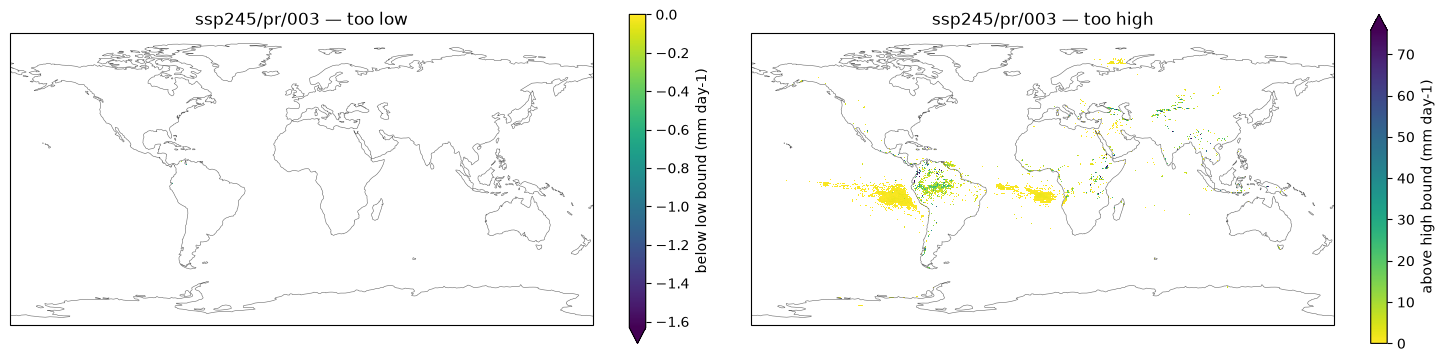

In [10]:
plot_exceedance_maps(deep_dive_stats)

In [11]:
s = deep_dive_stats[deep_dive_key]

## Part 2 — single-point drill-down

A map tells you *where* a leaf leaves the envelope; to understand *why*, it helps to look at one
grid cell across the whole record. Below we pick one flagged leaf and one point and plot the
downscaled daily values against the plausible envelope and the underlying inputs (raw scenario GCM,
raw historical GCM, ERA5 observations, and the coarse debiased output). Change `drill_key` and the
point to inspect any cell; the defaults below inspect a flagged `rsds` leaf. Every series in the
figure is converted to the leaf's reporting units before plotting, so an `rsds` drill-down reads in
W m⁻² on the same scale as the summary table above.

In [36]:
# Visually ind a point to inspect more closely (one that was flagged)
_preferred = ("ssp245", "pr", "003")
# s = stats[_preferred]
stats = deep_dive_stats
# under_to_plot = (s.under).where(s.under < 0)

In [37]:
ilat, ilon = 3.5, -77.3  # example point (store coordinate convention)

In [38]:
# Default to a known flagged leaf if present, else the first flagged leaf, else the first leaf.
if _preferred in stats:
    drill_key = _preferred
else:
    _flagged = summary.index[~summary["pass"]]
    drill_key = tuple(_flagged[0]) if len(_flagged) else next(iter(stats))
drill_scenario, drill_var, drill_member = drill_key

print(f"Drilling into {drill_scenario}/{drill_var}/{drill_member} at lat={ilat}, lon={ilon}")

# Rebuild the fine-grid bounds for this leaf, then select the single point (dask prunes the graph to
# the one column, so this stays cheap despite the global reindex expression).
low_obs, high_obs = obs_bounds_cached(drill_var)
_hist_member = historical_member(*drill_key)
raw_scenario = CESM[drill_scenario][drill_var].sel(ensemble_member=drill_member)
raw_historical = CESM["historical"][drill_var].sel(ensemble_member=_hist_member)
delta_low, delta_high = scenario_delta_doy(raw_scenario, raw_historical, window=WINDOW)
_regrid = {"lat": low_obs["lat"], "lon": low_obs["lon"], "method": "nearest"}

# Every series below — downscaled, envelope, raw GCM, ERA5, coarse debiased — is stored in the
# same units, so one scale converts the whole panel and the axes agree with the summary table.
# (ERA5 `pr` comes from mean_total_precipitation_rate and the raw CESM PRECT is CMORized to
# kg m-2 s-1 during ETL, so no series needs a different factor.)
drill_units, drill_scale = display_units(drill_var)

_pt = {"lat": ilat, "lon": ilon, "method": "nearest"}
pt_bound_high = (high_obs + delta_high.reindex(**_regrid)).sel(**_pt).compute() * drill_scale
pt_bound_low = (low_obs + delta_low.reindex(**_regrid)).sel(**_pt).compute() * drill_scale

pt_vals = leaves[drill_key].sel(**_pt).compute() * drill_scale
pt_obs = obs_fine(drill_var).sel(**_pt).compute() * drill_scale
pt_raw_scenario = raw_scenario.sel(**_pt).compute() * drill_scale
pt_raw_historical = raw_historical.sel(**_pt).compute() * drill_scale

_coarse_node = tree[f"debiased_coarse/{drill_scenario}"][f"{drill_var}/{drill_member}"]
pt_coarse = _coarse_node.dataset[drill_var].sel(**_pt).compute() * drill_scale

doy = pt_vals["time.dayofyear"]
pt_too_high = pt_vals > pt_bound_high.sel(dayofyear=doy)
pt_too_low = pt_vals < pt_bound_low.sel(dayofyear=doy)
_n_flagged = int((pt_too_high | pt_too_low).sum())
print(f"Flagged days at this point: {_n_flagged} of {pt_vals.sizes['time']}")

Drilling into ssp245/pr/003 at lat=3.5, lon=-77.3


/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(
/opt/coiled/env/lib/python3.13/site-packages/dask/array/core.py:3641: UserWarning: Passing an object to dask.array.from_array which is already a Dask collection. This can lead to unexpected behavior.
  warnings.warn(


Flagged days at this point: 35 of 31046


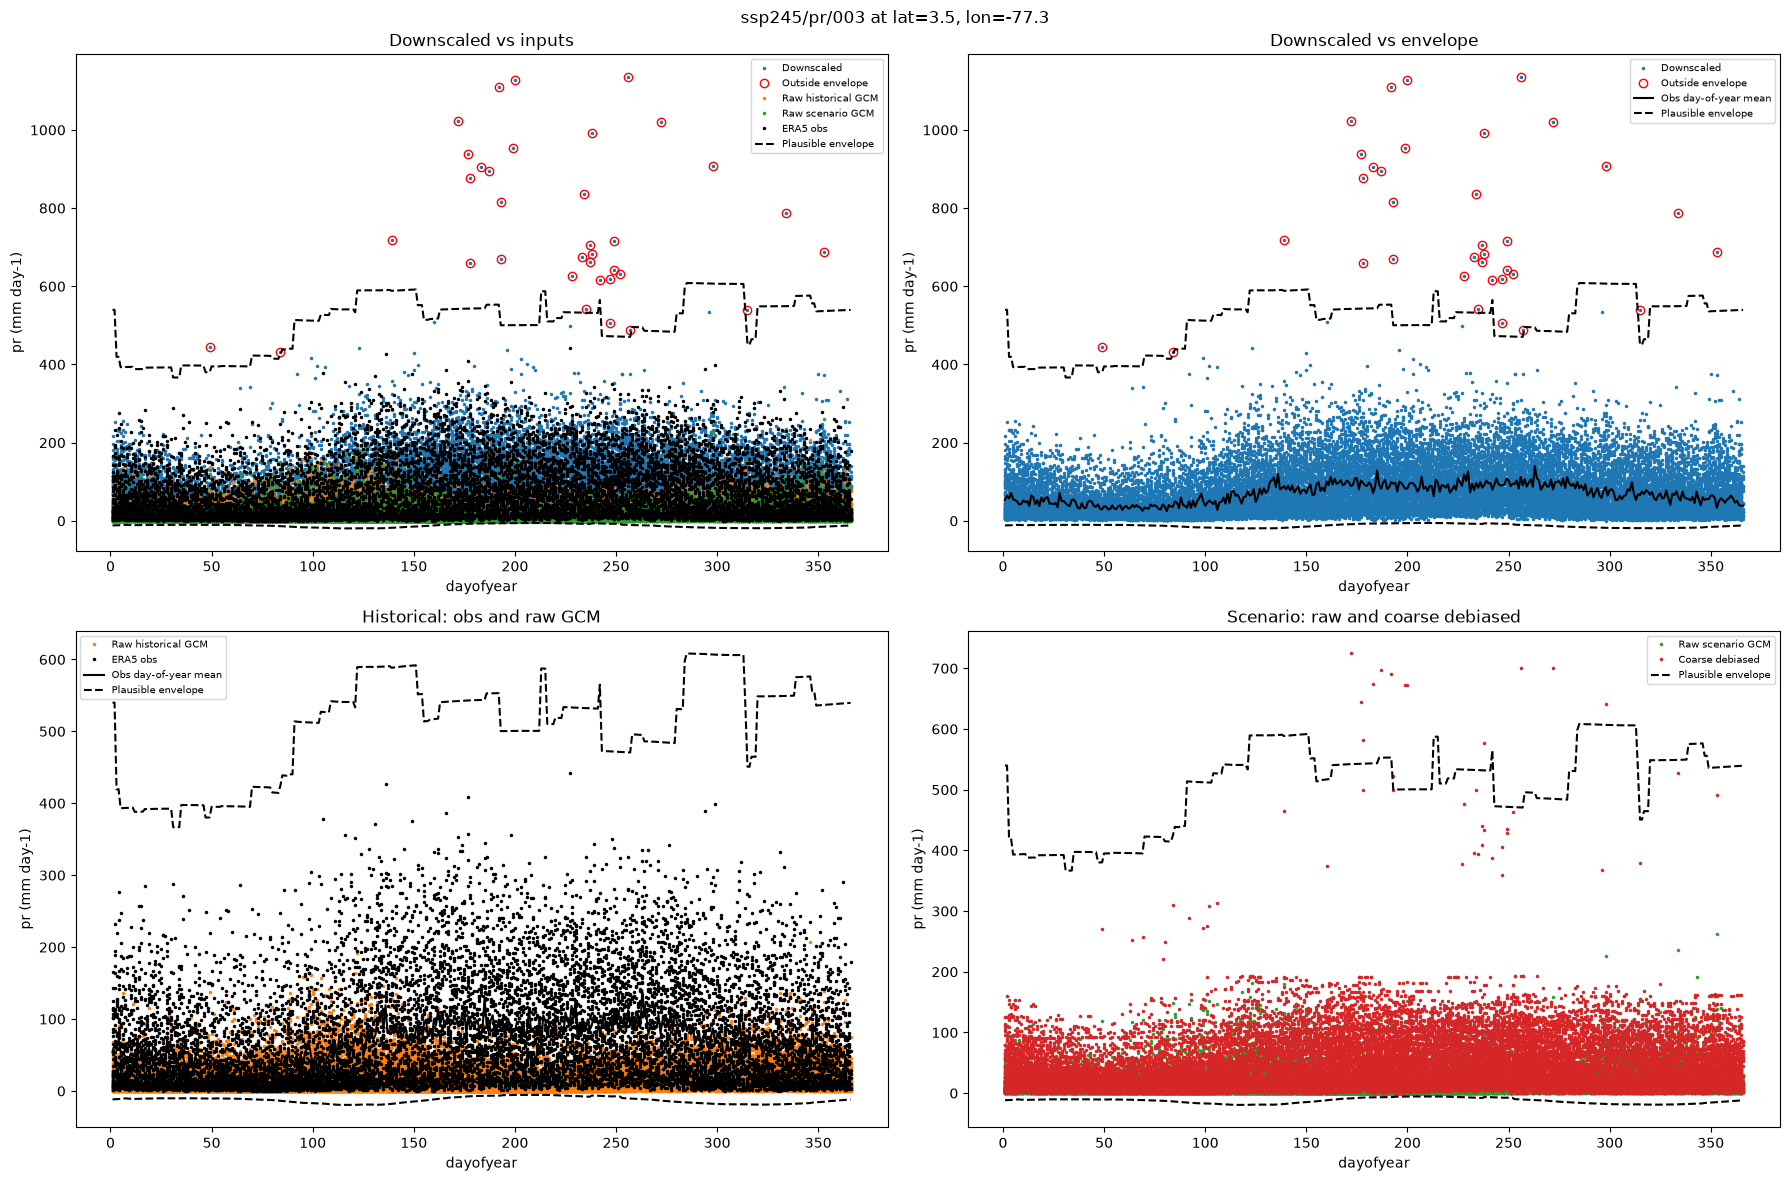

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
obs_doy_mean = pt_obs.groupby("time.dayofyear").mean()


def _series(ax, da, **kw):
    """Scatter a point time series against its day of year."""
    ax.plot(da["time.dayofyear"], da, ".", ms=3, **kw)


def _envelope(ax):
    """Overlay the plausible day-of-year envelope as dashed lines."""
    pt_bound_high.plot(ax=ax, color="black", ls="--", label="Plausible envelope")
    pt_bound_low.plot(ax=ax, color="black", ls="--")


def _outliers(ax):
    """Downscaled values, with red rings on the days that leave the envelope."""
    ax.plot(doy, pt_vals, ".", ms=3, label="Downscaled")
    ax.plot(doy, pt_vals.where(pt_too_high), "o", mfc="none", color="red", label="Outside envelope")
    ax.plot(doy, pt_vals.where(pt_too_low), "o", mfc="none", color="red")


# (0,0) Downscaled output vs envelope, with all inputs overlaid.
ax = axes[0, 0]
_outliers(ax)
_series(ax, pt_raw_historical, label="Raw historical GCM")
_series(ax, pt_raw_scenario, label="Raw scenario GCM")
_series(ax, pt_obs, color="black", label="ERA5 obs")
_envelope(ax)
ax.set_title("Downscaled vs inputs")
ax.legend(fontsize=7)

# (0,1) Downscaled output and envelope, with the observed day-of-year mean.
ax = axes[0, 1]
_outliers(ax)
ax.plot(obs_doy_mean["dayofyear"], obs_doy_mean, "-k", label="Obs day-of-year mean")
_envelope(ax)
ax.set_title("Downscaled vs envelope")
ax.legend(fontsize=7)

# (1,0) Historical: obs and raw GCM.
ax = axes[1, 0]
_series(ax, pt_raw_historical, color="C1", label="Raw historical GCM")
_series(ax, pt_obs, color="black", label="ERA5 obs")
ax.plot(obs_doy_mean["dayofyear"], obs_doy_mean, "-k", label="Obs day-of-year mean")
_envelope(ax)
ax.set_title("Historical: obs and raw GCM")
ax.legend(fontsize=7)

# (1,1) Scenario: raw GCM and coarse debiased.
ax = axes[1, 1]
_series(ax, pt_raw_scenario, color="C2", label="Raw scenario GCM")
_series(ax, pt_coarse, color="C3", label="Coarse debiased")
_envelope(ax)
ax.set_title("Scenario: raw and coarse debiased")
ax.legend(fontsize=7)

for ax in axes.flat:
    ax.set_ylabel(f"{drill_var} ({drill_units})")

fig.suptitle(f"{drill_scenario}/{drill_var}/{drill_member} at lat={ilat}, lon={ilon}")
plt.tight_layout()
plt.show()

## Summary

Each leaf reports the fraction of the domain that ever leaves its per-day-of-year plausible
envelope, in each direction, together with the largest exceedance — in kelvin, mm day⁻¹ for
precipitation, or W m⁻² for shortwave radiation — and a pass flag at the 2 % threshold. Because the
envelope is intentionally wide and day-of-year specific, a passing leaf is strong evidence that the
downscaling did not invent locally impossible values, while a flagged leaf points to specific cells
and days to inspect with the drill-down rather than to an automatic failure.

For the v0.12.0 store this covers 18 leaves — `tas`, `tasmax`, `tasmin`, `pr`, and `rsds` across the
`historical`, `ssp245`, and `g6_1p5k` groups. `tas` and `tasmax` pass at every leaf, staying under 1 %
flagged area in both directions. All four `pr` leaves pass: the flagged area stays at or below about
1.6 % on the upper bound, and — as anticipated — the lower bound barely registers, catching at most
0.003 % of the domain by no more than about 3 mm day⁻¹ because the observed day-of-year minimum is
itself zero nearly everywhere. Passing an area test does not make those cells uninteresting, though.
The worst upper-bound exceedance is 861 mm day⁻¹ in `historical/pr/r3i1p1f1`, followed by 697 and
678 mm day⁻¹ for the two `ssp245` members and 592 mm day⁻¹ for `g6_1p5k/pr/003`. Two `tasmin` leaves
cross the 2 % threshold: `ssp245/tasmin/008` (~4.0 % too low) and `g6_1p5k/tasmin/003` (~4.5 % too
low).

Every `rsds` leaf crosses the 2 % threshold by a wide margin in both directions, consistently across
`historical`, `ssp245`, and `g6_1p5k`: roughly 19 % of the domain flagged too high and 3.5 % too low
in each of the four leaves. The largest upper-bound exceedance is 148 W m⁻² (`ssp245/rsds/003`) and
the largest lower-bound exceedance is -99 W m⁻² (`g6_1p5k/rsds/003`). The single-point drill-down
above inspects `ssp245/rsds/003`.

The refactor keeps the original check's numbers but computes them differently: it discovers leaves
from the store instead of a hand-written list, builds every reduction lazily, computes the expensive
observed envelope once per variable, and evaluates that variable's leaves in one `dask.compute` on a
fixed, on-demand cluster. Batching by variable keeps each variable's leaves running in parallel while
bounding peak memory to one variable at a time, and the fixed on-demand pool removes the worker churn
— spot reclamation and adaptive downscaling — that made an all-at-once run lose its reduction
partials mid-compute.

In [41]:
cluster.shutdown()